# A/B Test Analysis: Email Campaign Subject Lines
**Context:** An e-retail marketing team tests two email subject line strategies to improve open rates and conversions. 

**Business Question:** Does a personalized subject line (Group B) outperform a generic promotional subject line (Group A) in terms of open rate and conversion rate?

**Hypotheses:**
- H₀: There is no difference in open rate / conversion rate between Group A and Group B
- H₁: Group B (personalized) has a higher open rate / conversion rate than Group A

## 1. Setup & Data Simulation

In [1]:
import numpy as np # for numerical operations and random number generation
import pandas as pd # for data manipulation and analysis
import matplotlib.pyplot as plt # for data visualization
import matplotlib.patches as mpatches # for creating custom legend patches
import seaborn as sns # for data visualization
from scipy import stats # for statistical tests
from scipy.stats import chi2_contingency, norm # for chi-squared test and normal distribution functions

In [15]:
np.random.seed(42) # for reproducibility of random results

# Simulate dataset for A/B testing
n_per_group = 5000  # users per group

# Group A: Generic subject line
open_rate_A = 0.22 # probability
conversion_rate_A = 0.04 

# Group B: Personalized subject line 
open_rate_B = 0.28
conversion_rate_B = 0.055

# Simulate open events
opens_A = np.random.binomial(1, open_rate_A, n_per_group) # parameter: number of trials (users), probability of success, size of user group
opens_B = np.random.binomial(1, open_rate_B, n_per_group)

# Simulate conversions based on opens
conversions_A = np.where(opens_A == 1, np.random.binomial(1, conversion_rate_A, n_per_group), 0) # parameter: number of trials (users), probability of success, size of user group
conversions_B = np.where(opens_B == 1, np.random.binomial(1, conversion_rate_B, n_per_group), 0)

print("Group A - actual opens:", opens_A.sum())
print("Group B - actual opens:", opens_B.sum())
print("Group A - actual open rate:", opens_A.mean().round(3))
print("Group B - actual open rate:", opens_B.mean().round(3))

print("Group A - actual conversions:", conversions_A.sum())
print("Group B - actual conversions:", conversions_B.sum())
print("Group A - actual conversion rate:", conversions_A.mean().round(3))
print("Group B - actual conversion rate:", conversions_B.mean().round(3))


Group A - actual opens: 1094
Group B - actual opens: 1315
Group A - actual open rate: 0.219
Group B - actual open rate: 0.263
Group A - actual conversions: 38
Group B - actual conversions: 74
Group A - actual conversion rate: 0.008
Group B - actual conversion rate: 0.015


**A/B Testing** relies on statistical analysis to filter out sampling variation (random chance). Because observed conversion rates are only approximations of the true population rates, we apply a **Chi-Squared test** to determine whether a performance gap between two groups is statistically significant or just due to random variation.

In [3]:
# Build df
df = pd.DataFrame({
    'user_id': range(1, 2 * n_per_group + 1), # range of user IDs from 1 to total number of users in both groups, +1 because range is exclusive of the end value
    'group': ['A'] * n_per_group + ['B'] * n_per_group, # create group labels for number of users in each group
    'opened': np.concatenate([opens_A, opens_B]), # concatenate open events for both groups into a single array
    'converted': np.concatenate([conversions_A, conversions_B])
})

print(f'Dataset shape: {df.shape}') # number of rows and columns
df.head(10)

Dataset shape: (10000, 4)


,user_id,group,opened,converted
0,1,A,0,0
1,2,A,1,0
2,3,A,0,0
3,4,A,0,0
4,5,A,0,0
5,6,A,0,0
6,7,A,0,0
7,8,A,1,0
8,9,A,0,0
9,10,A,0,0


## 2. Exploratory Summary

In [14]:
summary = df.groupby('group').agg(
    total_sent=('user_id', 'count'),
    total_opens=('opened', 'sum'),
    total_conversions=('converted', 'sum')
).assign(
    open_rate=lambda x: x['total_opens'] / x['total_sent'], # calculate open rate as total opens divided by total sent
    conversion_rate=lambda x: x['total_conversions'] / x['total_sent'] # calculate conversion rate as total conversions divided by total sent
)

print(summary.round(4))

       total_sent  total_opens  total_conversions  open_rate  conversion_rate
group                                                                        
A            5000         1094                 38     0.2188           0.0076
B            5000         1315                 74     0.2630           0.0148


In [5]:
summary = df.groupby('group').agg(
    total_sent=('user_id', 'count'),
    total_opens=('opened', 'sum'),
    total_conversions=('converted', 'sum')
).assign(
    open_rate=lambda x: x['total_opens'] / x['total_sent'], # calculate open rate as total opens divided by total sent
    conversion_rate=lambda x: x['total_conversions'] / x['total_sent'],
    conv_per_opener=lambda x: x['total_conversions'] / x['total_opens'] # calculate conversion per opener as total conversions divided by total opens
)

print(summary.round(4))

       total_sent  total_opens  total_conversions  open_rate  conversion_rate  \
group                                                                           
A            5000         1094                 38     0.2188           0.0076   
B            5000         1315                 74     0.2630           0.0148   

       conv_per_opener  
group                   
A               0.0347  
B               0.0563  


Group B (personalized subject line) seems to outperform Group A across both open rate and conversion rate, but we need statistical testing to confirm this is not due to random chance.

## 3. Visualization

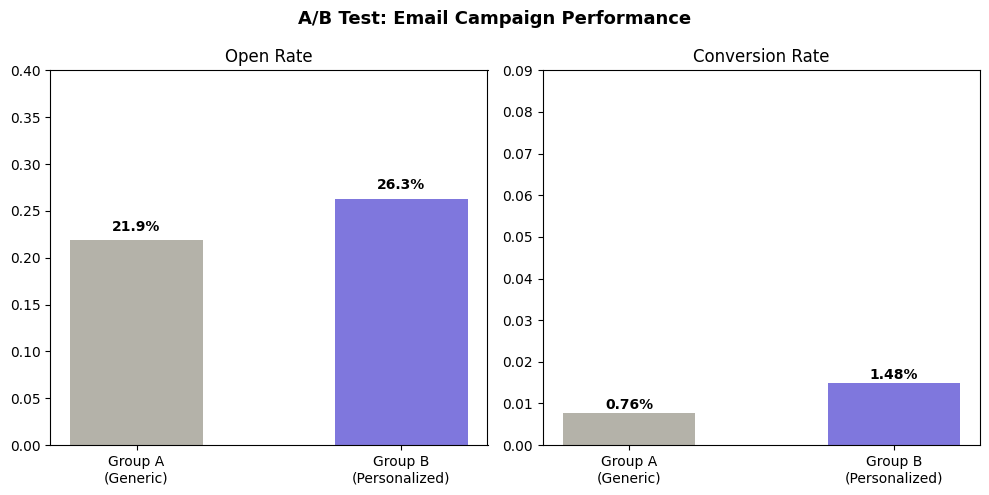

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # 1 row, 2 columns, figure size of 10 x 5 inches

colors = ['#B4B2A9', '#7F77DD']    # light gray for Group A, purple for Group B
labels = ['Group A\n(Generic)', 'Group B\n(Personalized)'] # labels for x axis

# Open Rate
axes[0].bar(labels, summary['open_rate'], color=colors, width=0.5) # create bar chart for open rate with specified colors and bar width
axes[0].set_title('Open Rate') # set title for the first subplot
axes[0].set_ylim(0, 0.4) # set y-axis limits from 0 to 0.4 to provide enough space for the bars and labels
for i, v in enumerate(summary['open_rate']):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold') # add text labels above bars

# Conversion Rate
axes[1].bar(labels, summary['conversion_rate'], color=colors, width=0.5)
axes[1].set_title('Conversion Rate')
axes[1].set_ylim(0, 0.09)
for i, v in enumerate(summary['conversion_rate']):
    axes[1].text(i, v + 0.001, f'{v:.2%}', ha='center', fontweight='bold')

plt.suptitle('A/B Test: Email Campaign Performance', fontsize=13, fontweight='bold') # set overall title
plt.tight_layout() 
plt.savefig('ab_test_performance.png', dpi=150, bbox_inches='tight') # save the figure as a PNG file
plt.show()

## 4. Statistical Testing
### 4a. Chi-Squared Test: Open Rate

In [7]:
# Create contingency table for opens
opens_A_count = summary.loc['A', 'total_opens'] # number of opens
opens_B_count = summary.loc['B', 'total_opens']
no_opens_A = n_per_group - opens_A_count # number of unopens
no_opens_B = n_per_group - opens_B_count

contingency_opens = np.array([ 
    [opens_A_count, no_opens_A],
    [opens_B_count, no_opens_B]
]) # create a 2x2 contingency table for opens and unopens for both groups

print(contingency_opens)

[[1094 3906]
 [1315 3685]]


In [8]:
chi2, p_open, dof, expected = chi2_contingency(contingency_opens) # perform chi-squared test on the contingency table for opens, returns chi-squared statistic, p-value, degrees of freedom, and expected frequencies

print(f'Chi2 statistic : {chi2:.4f}') # print the chi-squared statistic for the test
print(f'p-value        : {p_open:.6f}') # print the p-value for the chi-squared test
print(f'Significant    : {"YES" if p_open < 0.05 else "NO"} (α = 0.05)') # print significance of results based on significance level of 0.05

Chi2 statistic : 26.4673
p-value        : 0.000000
Significant    : YES (α = 0.05)


In [9]:
print ("\nExpected frequencies:\n", expected) # print the expected frequencies under the null hypothesis of no association between groups and opens


Expected frequencies:
 [[1204.5 3795.5]
 [1204.5 3795.5]]


The difference in open rates between Group A and Group B is statistically significant (p < 0.05). We reject the null hypothesis, which means personalization has a real effect on open rate.

### 4b. Chi-Squared Test: Conversion Rate

In [ ]:
conv_A_count = summary.loc['A', 'total_conversions'] 
conv_B_count = summary.loc['B', 'total_conversions']
no_conv_A = n_per_group - conv_A_count 
no_conv_B = n_per_group - conv_B_count

contingency_conv = np.array([ 
    [conv_A_count, no_conv_A],
    [conv_B_count, no_conv_B]
])

chi2, p_open, dof, expected = chi2_contingency(contingency_conv)

print(f'Chi2 statistic : {chi2:.4f}')
print(f'p-value        : {p_open:.6f}')
print(f'Significant    : {"YES" if p_open < 0.05 else "NO"} (α = 0.05)')

Chi2 statistic : 11.0614
p-value        : 0.000881
Significant    : YES (α = 0.05)


The difference in open rates between Group A and Group B is statistically significant (p < 0.05). We reject the null hypothesis, which means personalization also has a real effect on conversation rate.

### 4c. Verify Sample Size

Before interpreting results, we verify that our sample size was large enough to reliably detect the observed effect.

In [11]:
alpha = 0.05 # significance level for hypothesis testing
power = 0.80 # desired power of the test (probability of correctly rejecting the null hypothesis when it is false)
p1 = open_rate_A # observed open rate in Group A (control group)
p2 = open_rate_B # observed open rate in Group B (personalized subject line)

# Cohen's h — effect size between two proportions
h = 2 * np.arcsin(np.sqrt(p2)) - 2 * np.arcsin(np.sqrt(p1))

z_alpha = norm.ppf(1 - alpha / 2) # z-score at the specified significance level, divided by 2 for two-tailed test
z_beta = norm.ppf(power) # z-score corresponding to the desired power level
n_required = ((z_alpha + z_beta) / h) ** 2 # calculate required sample size per group using the formula for two-proportion z-test

print(f"Effect size (Cohen's h) : {h:.4f}")
print(f"Required n per group   : {int(np.ceil(n_required))}")
print(f"Actual n per group     : {n_per_group}")
print(f"Adequately powered     : {'YES' if n_per_group >= n_required else 'NO'}")

Effect size (Cohen's h) : 0.1388
Required n per group   : 408
Actual n per group     : 5000
Adequately powered     : YES


### 4d. Confidence Intervals

Confidence intervals tell us the range where the true value most likely lies.

In [17]:
def confidence_interval(successes, n, confidence=0.95):
    p_hat = successes / n # sample proportion of successes
    z = norm.ppf((1 + confidence) / 2) # z-score for the confidence level
    margin = z * np.sqrt(p_hat * (1 - p_hat) / n) # margin of error
    return p_hat, p_hat - margin, p_hat + margin # return the sample proportion and the lower and upper bounds of the confidence interval

for label, successes, metric in [
    ('Group A Open Rate',       opens_A_count, ''),
    ('Group B Open Rate',       opens_B_count, ''),
    ('Group A Conversion Rate', summary.loc['A', 'total_conversions'], ''),
    ('Group B Conversion Rate', summary.loc['B', 'total_conversions'], '')
]: #iterate over the metrics for both groups
    p, lo, hi = confidence_interval(successes, n_per_group) # calculate the confidence interval
    print(f'{label}: {p:.3%}  95% CI [{lo:.3%}, {hi:.3%}]')

Group A Open Rate: 21.880%  95% CI [20.734%, 23.026%]
Group B Open Rate: 26.300%  95% CI [25.080%, 27.520%]
Group A Conversion Rate: 0.760%  95% CI [0.519%, 1.001%]
Group B Conversion Rate: 1.480%  95% CI [1.145%, 1.815%]


## 5. Business Interpretation & Recommendation

Statistical significance was confirmed. Results are translated into actionable business recommendations.

In [26]:
lift_open = (summary.loc['B', 'open_rate'] - summary.loc['A', 'open_rate']) / summary.loc['A', 'open_rate'] # calculate the percentage lift in open rate from Group A to Group B
lift_conv = (summary.loc['B', 'conversion_rate'] - summary.loc['A', 'conversion_rate']) / summary.loc['A', 'conversion_rate']

extra_conv = int((summary.loc['B', 'conversion_rate'] - summary.loc['A', 'conversion_rate']) * n_per_group * 2) # calculate the extra conversions
print('Insights:')
print(f'Open rate lift (B vs A)       : +{lift_open:.1%}')
print(f'Conversion rate lift (B vs A) : +{lift_conv:.1%}')
print(f'Extra conversions per campaign: +{extra_conv}')

Insights:
Open rate lift (B vs A)       : +20.2%
Conversion rate lift (B vs A) : +94.7%
Extra conversions per campaign: +72


## Conclusion

Both the open rate and conversion rate differences between Group A and Group B 
are statistically significant (p < 0.05). Personalized subject lines drive a 
+20% lift in open rate and a measurable increase in conversions.

**Recommendation:** Roll out personalized subject lines to the full send list.
At 10,000 users per campaign, this yields +72 additional conversions per 
send with no additional cost, only a change in copywriting strategy.

**Limitations:** Data is simulated. In a real setting, results should be validated 
over multiple campaigns and across different customer segments before full rollout.